In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [22]:
df = pd.read_csv('Walmart_Sales.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [23]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


None

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [24]:
display(df.duplicated().sum())
df.isna().sum()

np.int64(0)

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [25]:
df = df.drop_duplicates()
df = df.dropna()

In [26]:
scaler = StandardScaler()

df['High_Sales'] = (df['Weekly_Sales'] > df['Weekly_Sales'].median()).astype(int)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

X = df.drop(columns=['Weekly_Sales', 'Date', 'High_Sales'])  # keep engineered time features
y = df['High_Sales'].values.reshape(-1, 1)

# Scale the features (X) and the target variable (y)
y_scaled = scaler.fit_transform(y)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

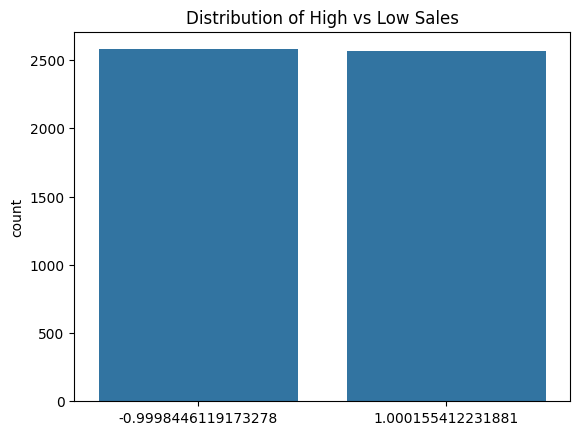

In [27]:
sns.countplot(x=y_train.flatten())
plt.title("Distribution of High vs Low Sales")
plt.show()

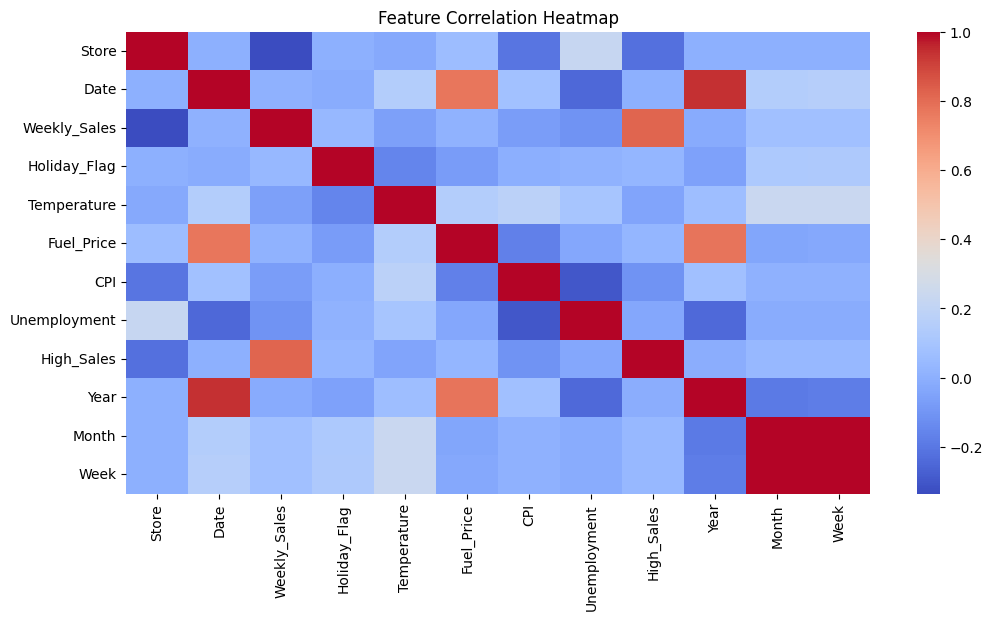

In [28]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [36]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train.flatten().astype(int))
y_pred_lr = log_reg.predict(X_test)

y_pred_lr

array([1, 1, 1, ..., 0, 1, 1])

In [37]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train.flatten().astype(int))
y_pred_rf = rf.predict(X_test)

y_pred_rf

array([1, 1, 1, ..., 0, 1, 0])

In [40]:
svm = SVC(probability=True)
svm.fit(X_train, y_train.flatten().astype(int))
y_pred_svm = svm.predict(X_test)

y_pred_svm

array([1, 1, 1, ..., 0, 1, 1])

In [42]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    # Convert y_test to binary integers to match predictions
    y_test_binary = y_test.flatten().astype(int)
    return {
        "Accuracy": accuracy_score(y_test_binary, preds),
        "Precision": precision_score(y_test_binary, preds),
        "Recall": recall_score(y_test_binary, preds),
        "F1": f1_score(y_test_binary, preds),
        "ROC-AUC": roc_auc_score(y_test_binary, probs)
    }

print(evaluate(log_reg, X_test, y_test))
print(evaluate(rf, X_test, y_test))
print(evaluate(svm, X_test, y_test))

{'Accuracy': 0.6348096348096348, 'Precision': 0.6232686980609419, 'Recall': 0.6944444444444444, 'F1': 0.656934306569343, 'ROC-AUC': np.float64(0.6773652891284607)}
{'Accuracy': 0.9533799533799534, 'Precision': 0.9495412844036697, 'Recall': 0.9583333333333334, 'F1': 0.9539170506912442, 'ROC-AUC': np.float64(0.98938107382291)}
{'Accuracy': 0.7466977466977467, 'Precision': 0.7439393939393939, 'Recall': 0.7577160493827161, 'F1': 0.7507645259938838, 'ROC-AUC': np.float64(0.8273899225255511)}


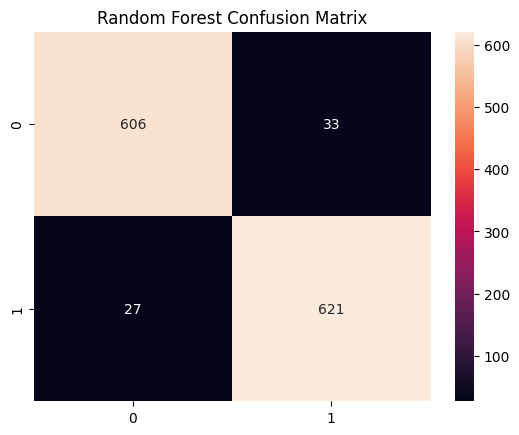

In [44]:
from sklearn.metrics import confusion_matrix

# Convert y_test to binary integers to match the predictions
y_test_binary = y_test.flatten().astype(int)

sns.heatmap(confusion_matrix(y_test_binary, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

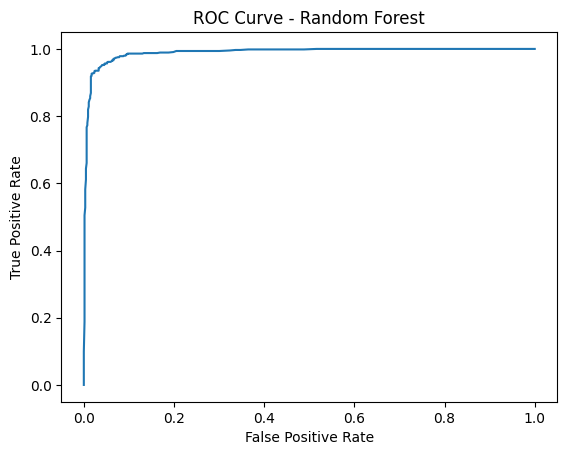

In [46]:
probs = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test_binary, probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()